In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Dense, Dropout, SimpleRNN, LSTM
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.layers import GRU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight



c:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## EDA

In [2]:
df = pd.read_csv("AirQualityUCI.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9824 entries, 0 to 9823
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9824 non-null   object 
 1   Time           9824 non-null   object 
 2   CO(GT)         9332 non-null   float64
 3   PT08.S1(CO)    9824 non-null   float64
 4   NMHC(GT)       9824 non-null   int64  
 5   C6H6(GT)       9824 non-null   float64
 6   PT08.S2(NMHC)  9824 non-null   float64
 7   NOx(GT)        9824 non-null   float64
 8   PT08.S3(NOx)   9824 non-null   float64
 9   NO2(GT)        9824 non-null   float64
 10  PT08.S4(NO2)   9824 non-null   float64
 11  PT08.S5(O3)    9824 non-null   float64
 12  T              9824 non-null   float64
 13  RH             9824 non-null   float64
 14  AH             9824 non-null   float64
dtypes: float64(12), int64(1), object(2)
memory usage: 1.1+ MB


In [4]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9332.000000,9824.000000,9824.000000,9824.000000,9824.000000,9824.000000,9824.000000,9824.000000,9824.000000,9824.000000,9824.000000,9824.000000,9824.000000
mean,-34.002497,1047.680773,-158.985240,1.737645,893.686143,168.650957,794.511087,58.269900,1390.596252,974.155436,9.641289,39.353574,-6.954899
std,77.484771,330.934214,139.822617,41.663209,343.056221,257.200410,322.730153,126.791413,468.385339,457.399490,43.497226,51.538991,39.254314
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,919.500000,-200.000000,4.009478,711.250000,50.200000,637.750000,53.000000,1183.750000,699.625000,10.893750,34.143750,0.692088
50%,1.500000,1052.000000,-200.000000,7.886653,894.500000,140.800000,794.875000,96.000000,1446.500000,942.000000,17.200000,48.550000,0.974232
75%,2.600000,1220.750000,-200.000000,13.628473,1104.500000,284.000000,960.000000,133.000000,1661.750000,1252.750000,24.050000,61.874999,1.296678
max,11.900000,2039.750000,1189.000000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036


In [5]:
print("Shape of the data:", df.shape)

Shape of the data: (9824, 15)


In [6]:
df.head(3)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.6,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.3,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.9,53.975000,0.750239


In [7]:
df.tail(3)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9821,2004-03-22,08:00:00,3.6,1514.25,-200,17.686444,1230.25,226.0,732.0,116.0,1996.25,1252.25,15.800,53.700000,0.957133
9822,2005-02-26,09:00:00,1.5,933.00,-200,4.054799,713.75,227.1,898.5,133.3,926.75,705.75,6.725,49.474999,0.489157
9823,2004-11-29,08:00:00,4.2,1439.50,-200,20.553561,1311.75,760.0,536.5,120.0,1656.75,1515.25,9.625,80.825001,0.968683


In [8]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

## visualizations

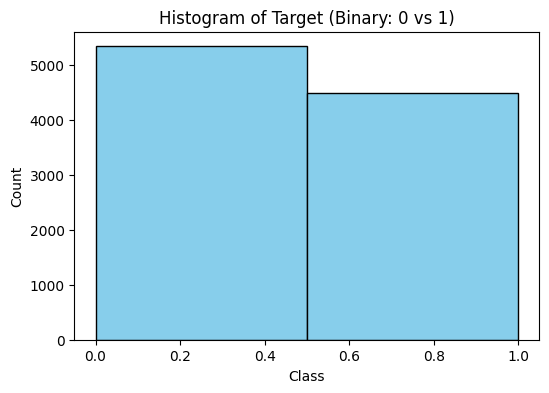

In [9]:
# Histogram 
df_encoded = df.copy()

# Create binary target based on median of CO(GT)
df_encoded['Target'] = (df_encoded['CO(GT)'] > df_encoded['CO(GT)'].median()).astype(int)

# Assign target to y
y = df_encoded['Target']

# plot histogram
plt.figure(figsize=(6,4))
plt.hist(y, bins=2, color='skyblue', edgecolor='black')
plt.title("Histogram of Target (Binary: 0 vs 1)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

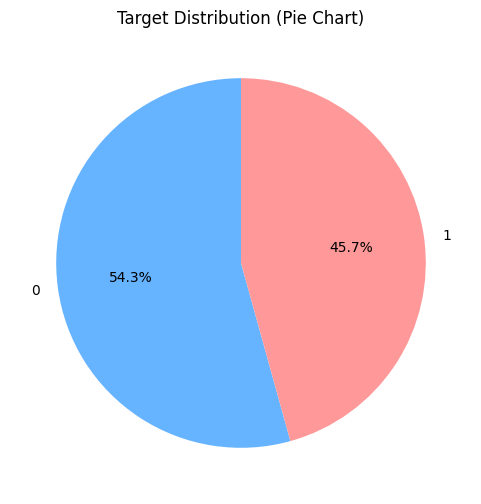

In [10]:
# Pie chart 
target_counts = y.value_counts()
plt.figure(figsize=(6,6))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title("Target Distribution (Pie Chart)")
plt.show()

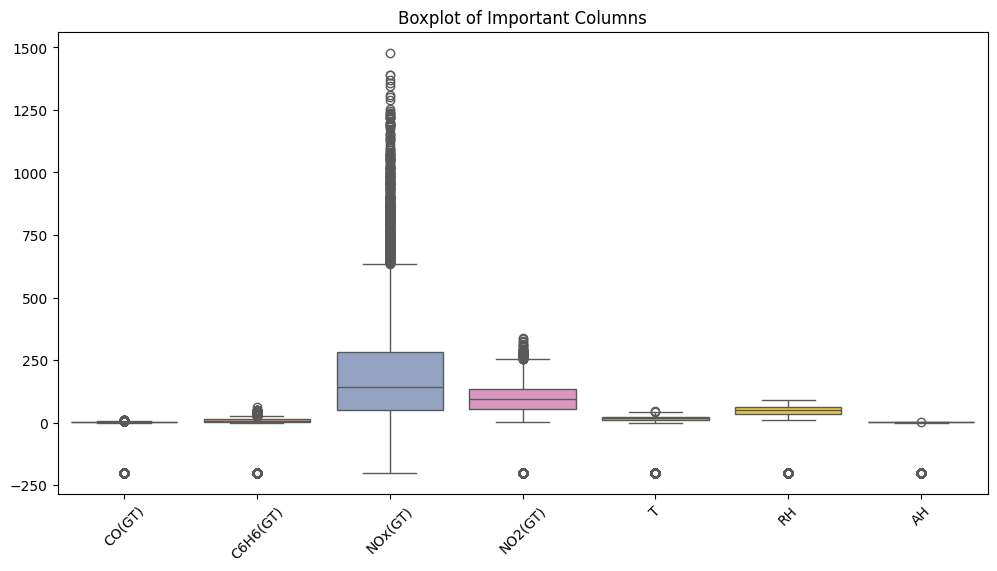

In [11]:
# Boxplot: 
important_columns = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']

plt.figure(figsize=(12,6))
sns.boxplot(data=df[important_columns], palette="Set2")
plt.title("Boxplot of Important Columns")
plt.xticks(rotation=45)
plt.show()

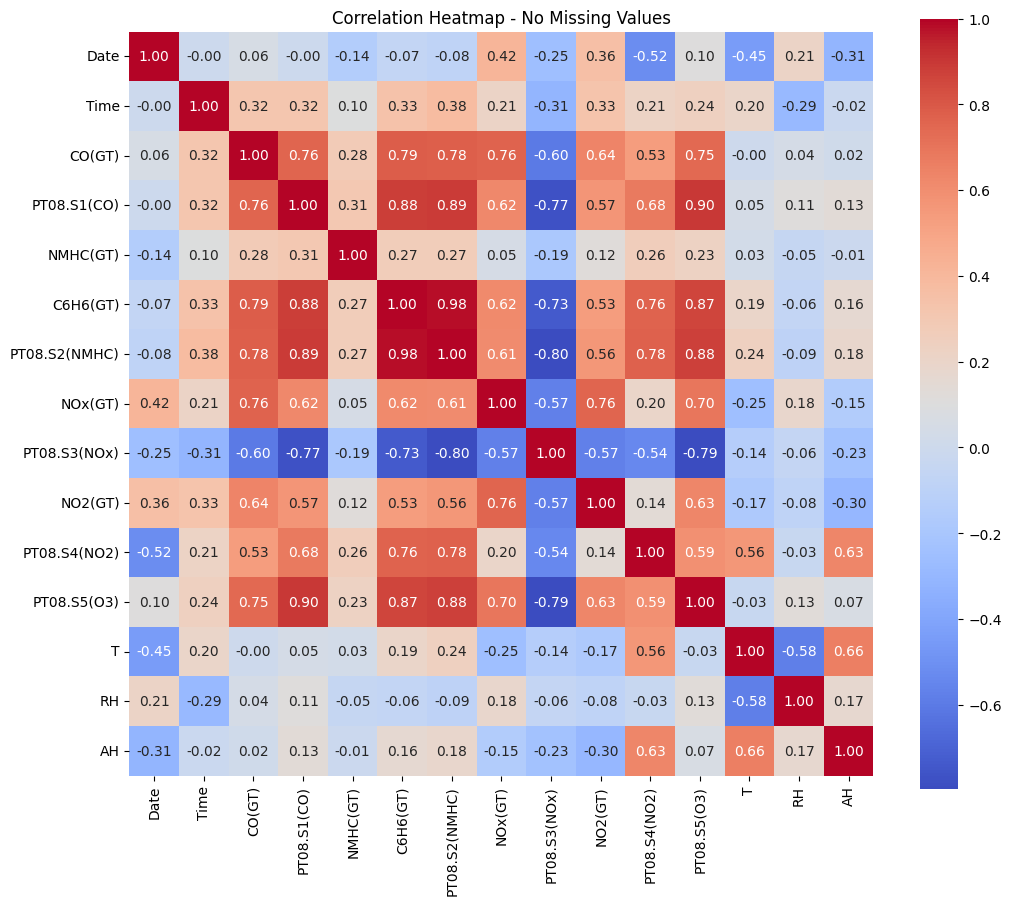

In [12]:
# Correlation 

# Copy dataset
df_encoded = df.copy()

# Replace placeholder -200 with NaN
df_encoded = df_encoded.replace(-200, np.nan)

# Fill NaN with median of each column (numeric only)
for col in df_encoded.select_dtypes(include=['float64','int64']).columns:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

# Encode categorical columns
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Compute correlation
corr = df_encoded.corr()

# Plot heatmap with masking for upper triangle (optional) and better colormap
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap - No Missing Values")
plt.show()



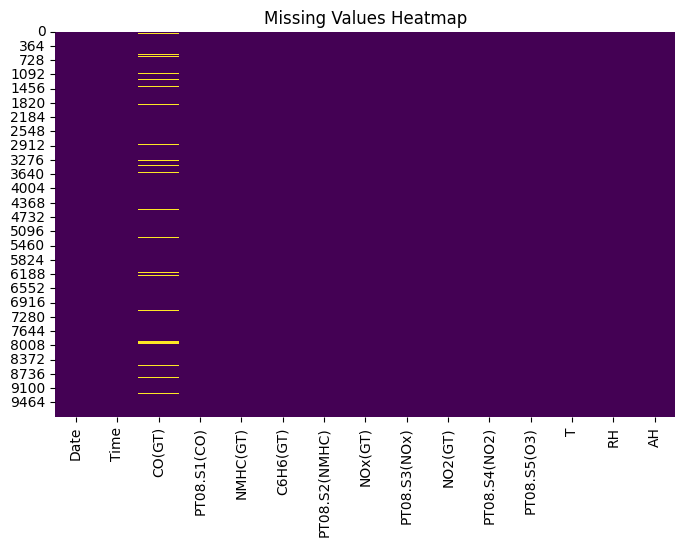

In [13]:
# Visualize missing values 
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

## pre-processing

In [14]:
# Check missing values
print("\n Missing Values: ")
df.isnull().sum()


 Missing Values: 


Date               0
Time               0
CO(GT)           492
PT08.S1(CO)        0
NMHC(GT)           0
C6H6(GT)           0
PT08.S2(NMHC)      0
NOx(GT)            0
PT08.S3(NOx)       0
NO2(GT)            0
PT08.S4(NO2)       0
PT08.S5(O3)        0
T                  0
RH                 0
AH                 0
dtype: int64

In [15]:
# Calculate and print missing values percentage
print("\n Missing Values Percentage: ")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)


 Missing Values Percentage: 
Date             0.000000
Time             0.000000
CO(GT)           5.008143
PT08.S1(CO)      0.000000
NMHC(GT)         0.000000
C6H6(GT)         0.000000
PT08.S2(NMHC)    0.000000
NOx(GT)          0.000000
PT08.S3(NOx)     0.000000
NO2(GT)          0.000000
PT08.S4(NO2)     0.000000
PT08.S5(O3)      0.000000
T                0.000000
RH               0.000000
AH               0.000000
dtype: float64


In [16]:
# Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            # fill categorical/object columns with the mode (most frequent value)
            mode_vals = df[col].mode()
            if not mode_vals.empty:
                df[col] = df[col].fillna(mode_vals.iloc[0])
            else:
                df[col] = df[col].fillna('')  # fallback if mode is not available
        else:
            # fill numeric columns with median
            df[col] = df[col].fillna(df[col].median())
print("\n Missing Values After Imputation: ")
print(df.isnull().sum())


 Missing Values After Imputation: 
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [17]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 467


In [18]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [19]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [20]:
# Print number of outliers for each column

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)  
    Q3 = df[col].quantile(0.75)  
    IQR = Q3 - Q1                 
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"Column '{col}' has {outliers.shape[0]} outliers")


Column 'CO(GT)' has 1872 outliers
Column 'PT08.S1(CO)' has 484 outliers
Column 'NMHC(GT)' has 914 outliers
Column 'C6H6(GT)' has 606 outliers
Column 'PT08.S2(NMHC)' has 427 outliers
Column 'NOx(GT)' has 509 outliers
Column 'PT08.S3(NOx)' has 601 outliers
Column 'NO2(GT)' has 1696 outliers
Column 'PT08.S4(NO2)' has 450 outliers
Column 'PT08.S5(O3)' has 457 outliers
Column 'T' has 368 outliers
Column 'RH' has 366 outliers
Column 'AH' has 367 outliers


In [21]:
# Cap outliers at the 1.5*IQR boundaries
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


In [22]:
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)  
    Q3 = df[col].quantile(0.75)  
    IQR = Q3 - Q1                 
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"Column '{col}' has {outliers.shape[0]} outliers")

Column 'CO(GT)' has 0 outliers
Column 'PT08.S1(CO)' has 0 outliers
Column 'NMHC(GT)' has 0 outliers
Column 'C6H6(GT)' has 0 outliers
Column 'PT08.S2(NMHC)' has 0 outliers
Column 'NOx(GT)' has 0 outliers
Column 'PT08.S3(NOx)' has 0 outliers
Column 'NO2(GT)' has 0 outliers
Column 'PT08.S4(NO2)' has 0 outliers
Column 'PT08.S5(O3)' has 0 outliers
Column 'T' has 0 outliers
Column 'RH' has 0 outliers
Column 'AH' has 0 outliers


In [23]:
df_encoded = df.copy()

# Encode categorical/object columns
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Numeric columns    
numeric_cols = df_encoded.select_dtypes(include=np.number).columns

# Difference feature
for col in numeric_cols:
    df_encoded[f'{col}_diff'] = df_encoded[col].diff().fillna(0)

# Squared feature
for col in numeric_cols:
    df_encoded[f'{col}_squared'] = df_encoded[col]**2

# Ratio feature example: NOx / CO
if 'NOx(GT)' in df_encoded.columns and 'CO(GT)' in df_encoded.columns:
    df_encoded['NOx_CO_ratio'] = df_encoded['NOx(GT)'] / (df_encoded['CO(GT)'] + 1e-5)

# Define binary target for next-hour prediction
sequence_length = 6
target_shift = 1

X_seq = []
y_seq = []

for i in range(len(df_encoded) - sequence_length - target_shift + 1):
    X_seq.append(df_encoded.iloc[i:i+sequence_length].drop(columns=['CO(GT)','Target'], errors='ignore').values)
    y_seq.append((df_encoded['CO(GT)'].iloc[i+sequence_length+target_shift-1] > df_encoded['CO(GT)'].quantile(0.75)).astype(int))

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)


# Split dataset

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

# Scaling features
num_samples, seq_len, num_features = X_train_seq.shape

# Flatten for scaler
X_train_flat = X_train_seq.reshape((num_samples, seq_len*num_features))
X_test_flat  = X_test_seq.reshape((X_test_seq.shape[0], seq_len*num_features))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled  = scaler.transform(X_test_flat)

# Reshape back for sequence models
X_train_seq = X_train_scaled.reshape((num_samples, seq_len, num_features))
X_test_seq  = X_test_scaled.reshape((X_test_seq.shape[0], seq_len, num_features))

# ANN uses flat features
X_train_ann = X_train_scaled
X_test_ann  = X_test_scaled
y_train_ann = y_train_seq
y_test_ann  = y_test_seq

# Compute class weights

class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)
class_weights = {i: class_weights_values[i] for i in range(len(class_weights_values))}
print("Class Weights:", class_weights)


# Early stopping callback

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)


Class Weights: {0: np.float64(0.6611278062577338), 1: np.float64(2.0515633571036753)}


## Training Models

In [24]:
# Function to plot Accuracy & Loss
def plot_acc_loss(history, title="Model"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc)+1)
    
    plt.figure(figsize=(14,5))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label='Training Acc')
    plt.plot(epochs, val_acc, label='Validation Acc')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()



Epoch 1/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8036 - loss: 0.5428 - val_accuracy: 0.8262 - val_loss: 0.4564
Epoch 2/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8390 - loss: 0.4521 - val_accuracy: 0.8422 - val_loss: 0.4270
Epoch 3/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8488 - loss: 0.4232 - val_accuracy: 0.8516 - val_loss: 0.4070
Epoch 4/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8553 - loss: 0.4003 - val_accuracy: 0.8235 - val_loss: 0.4353
Epoch 5/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 0.3842 - val_accuracy: 0.8529 - val_loss: 0.3995
Epoch 6/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8577 - loss: 0.3683 - val_accuracy: 0.8275 - val_loss: 0.4140
Epoch 7/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8602 - loss: 0.3556 - val_accuracy: 0.8262 - val_loss: 0.4256
Epoch 8/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8624 - loss: 0.3464 - val_accuracy: 0.

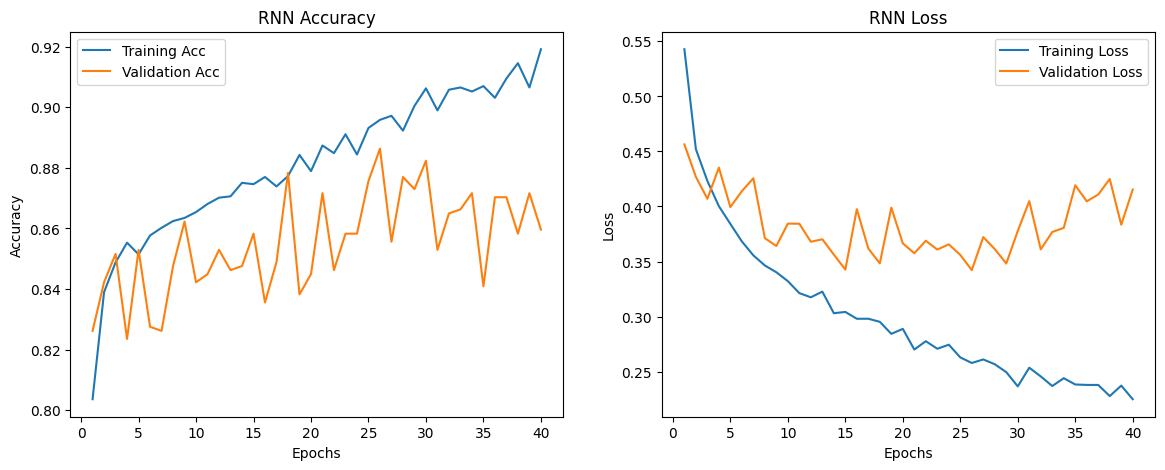

In [25]:
# Build RNN Model
model_rnn = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),  
    SimpleRNN(64, kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_rnn = model_rnn.fit(
    X_train_seq,
    y_train_seq,
    epochs=40,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weights
)

y_pred_rnn = (model_rnn.predict(X_test_seq) > 0.5).astype(int)
print("RNN Accuracy:", accuracy_score(y_test_seq, y_pred_rnn))
plot_acc_loss(history_rnn, "RNN")



Epoch 1/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8082 - loss: 0.7043 - val_accuracy: 0.8489 - val_loss: 0.5885
Epoch 2/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8351 - loss: 0.5877 - val_accuracy: 0.8650 - val_loss: 0.5171
Epoch 3/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8442 - loss: 0.5246 - val_accuracy: 0.8289 - val_loss: 0.5242
Epoch 4/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8552 - loss: 0.4915 - val_accuracy: 0.8529 - val_loss: 0.4785
Epoch 5/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8507 - loss: 0.4594 - val_accuracy: 0.8382 - val_loss: 0.4553
Epoch 6/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8561 - loss: 0.4344 - val_accuracy: 0.8382 - val_loss: 0.4402
Epoch 7/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8565 - loss: 0.4168 - val_accuracy: 0.8650 - val_loss: 0.4101
Epoch 8/40
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8626 - loss: 0.4005 - val_accuracy: 0.

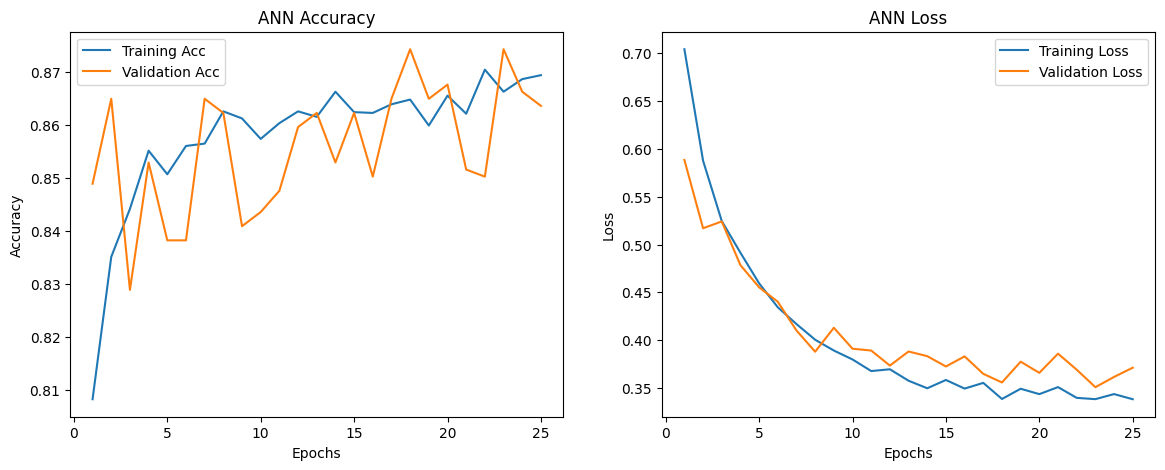

In [26]:
# ANN Model
model_ann = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_ann = model_ann.fit(
    X_train_scaled,
    y_train_ann,
    epochs=40,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weights
)

y_pred_ann = (model_ann.predict(X_test_scaled) > 0.5).astype(int)
print("ANN Accuracy:", accuracy_score(y_test_ann, y_pred_ann))

plot_acc_loss(history_ann, "ANN")


Epoch 1/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8091 - loss: 0.5574 - val_accuracy: 0.8583 - val_loss: 0.4410
Epoch 2/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8538 - loss: 0.4423 - val_accuracy: 0.8249 - val_loss: 0.4501
Epoch 3/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8552 - loss: 0.4024 - val_accuracy: 0.8570 - val_loss: 0.3832
Epoch 4/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8653 - loss: 0.3722 - val_accuracy: 0.8436 - val_loss: 0.3957
Epoch 5/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8654 - loss: 0.3549 - val_accuracy: 0.8529 - val_loss: 0.3798
Epoch 6/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8630 - loss: 0.3438 - val_accuracy: 0.8396 - val_loss: 0.4002
Epoch 7/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8696 - loss: 0.3245 - val_accuracy: 0.8650 - val_loss: 0.3623
Epoch 8/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8724 - loss: 0.3194 - val_accuracy: 0.

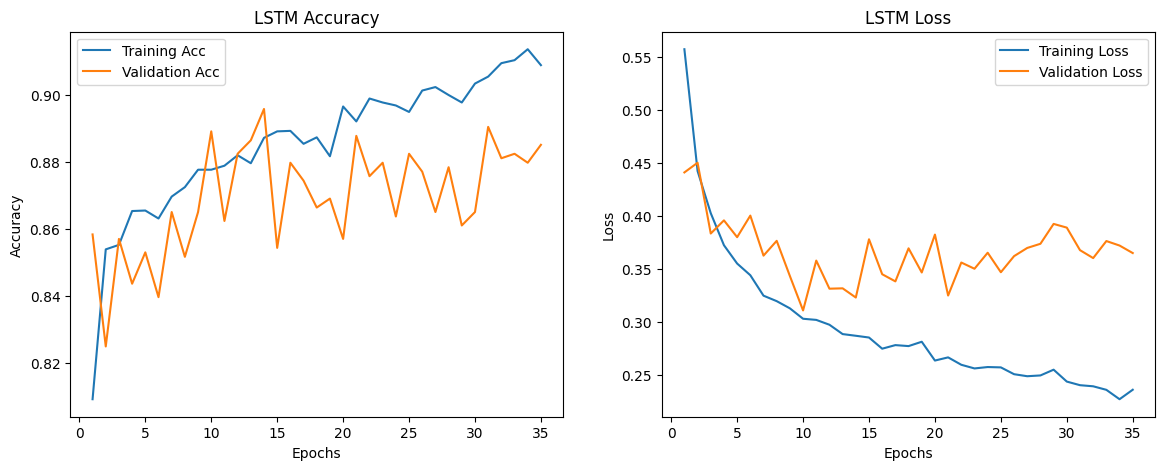

In [27]:
# Build LSTM Model
model_lstm = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])), 
    LSTM(128, kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_lstm = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weights
)
y_pred_lstm = (model_lstm.predict(X_test_seq) > 0.5).astype(int)
print("LSTM Accuracy:", accuracy_score(y_test_seq, y_pred_lstm))
plot_acc_loss(history_lstm, "LSTM")



---- ANN ----
Accuracy: 0.8450026723677178
              precision    recall  f1-score   support

           0       0.96      0.83      0.89      1415
           1       0.63      0.90      0.74       456

    accuracy                           0.85      1871
   macro avg       0.79      0.86      0.81      1871
weighted avg       0.88      0.85      0.85      1871



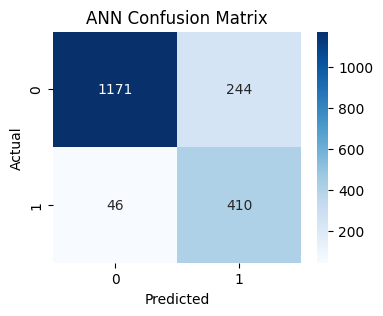


---- RNN ----
Accuracy: 0.880277926242651
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      1415
           1       0.70      0.89      0.78       456

    accuracy                           0.88      1871
   macro avg       0.83      0.88      0.85      1871
weighted avg       0.90      0.88      0.88      1871



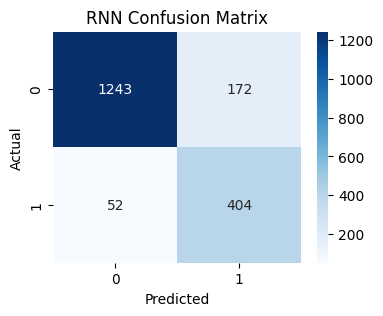


---- LSTM ----
Accuracy: 0.8850881881346874
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      1415
           1       0.72      0.87      0.79       456

    accuracy                           0.89      1871
   macro avg       0.84      0.88      0.85      1871
weighted avg       0.90      0.89      0.89      1871



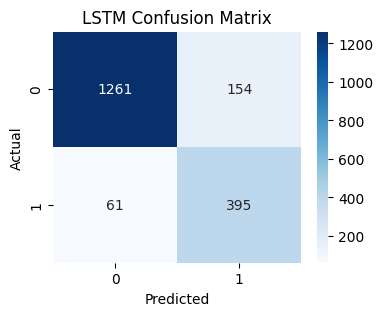

In [28]:
# Evaluate all models
models_preds = {
    'ANN': y_pred_ann,
    'RNN': y_pred_rnn,
    'LSTM': y_pred_lstm
    
}
acc_scores = [accuracy_score(y_test_seq, y_pred_rnn),
              accuracy_score(y_test_seq, y_pred_lstm),
              accuracy_score(y_test_ann, y_pred_ann)]

for name, preds in models_preds.items():
    print(f"\n---- {name} ----")
    y_true = y_test_ann if name == 'ANN' else y_test_seq
    print("Accuracy:", accuracy_score(y_true, preds))
    print(classification_report(y_true, preds))
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()




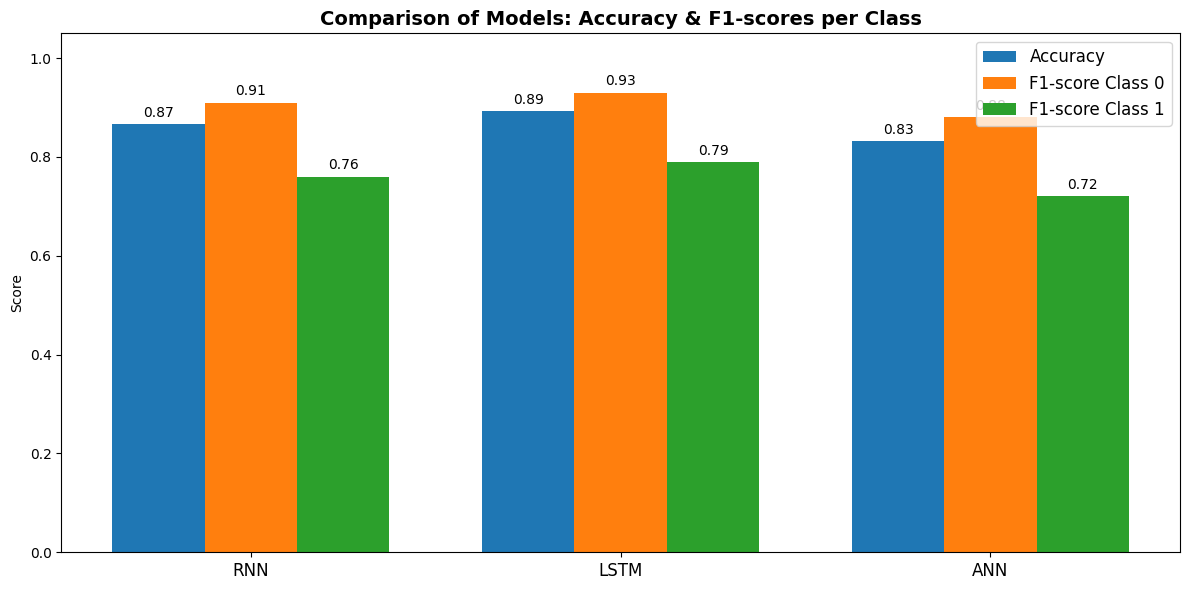

In [29]:
# Visualization of model comparison 
models = ['RNN', 'LSTM', 'ANN']

accuracy = [0.866, 0.892, 0.832]
f1_class_0 = [0.91, 0.93, 0.88]
f1_class_1 = [0.76, 0.79, 0.72]

x = np.arange(len(models))  
width = 0.25  

fig, ax = plt.subplots(figsize=(12,6))

rects1 = ax.bar(x - width, accuracy, width, label='Accuracy')
rects2 = ax.bar(x, f1_class_0, width, label='F1-score Class 0')
rects3 = ax.bar(x + width, f1_class_1, width, label='F1-score Class 1')

ax.set_ylabel('Score')
ax.set_ylim(0,1.05)
ax.set_title('Comparison of Models: Accuracy & F1-scores per Class',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=12)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()
